0.8777589134125636
0.8816793893129771
Intercept: [-4.26998942]
Coefficients: [[ 0.48036129 -0.40975871  0.43404005 -0.36448265 -0.11651669 -0.21130096
   0.4111985  -0.00149404  0.08346971  0.04817178  0.61116832  0.957572
  -0.55267731 -0.08506043  0.8409779  -0.03577117 -0.51584887 -0.16085981
  -0.57425501  0.07234282]]
Confusion matrix:
 [[762  10]
 [ 10   4]]
Precision: 0.2857142857142857
Recall: 0.2857142857142857


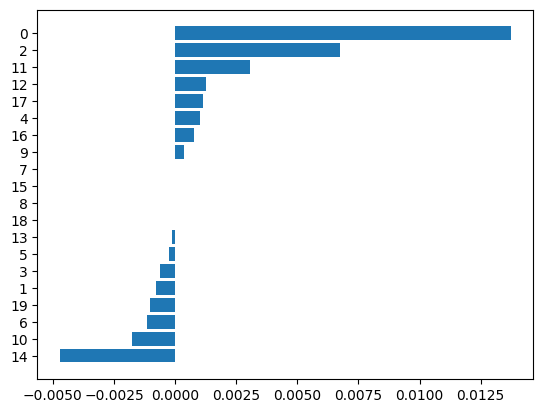

[-4.70737913e-03 -1.78117048e-03 -1.14503817e-03 -1.01781170e-03
 -7.63358779e-04 -6.36132316e-04 -2.54452926e-04 -1.27226463e-04
 -2.22044605e-17  0.00000000e+00  0.00000000e+00  0.00000000e+00
  3.81679389e-04  7.63358779e-04  1.01781170e-03  1.14503817e-03
  1.27226463e-03  3.05343511e-03  6.74300254e-03  1.37404580e-02]


In [119]:
#DV: rating row[8]
#IDVs: abv - row[6], raters - row[9], text - row[12]-row[30]
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance

#import data from CSVs
data = []
files=["../2_Database/TopBeerData.csv","../2_Database/GoodBeerData.csv","../2_Database/RestBeerData.csv"]
for i in range (0,len(files)):
    with open(files[i],"r",encoding="utf-8") as file:
        reader = csv.reader(file)
        for row in reader:
            row.append(i)
            data.append(row)

all_numeric_data = []
numeric_data = []
for row in data[1:]:  # ignore heading
    numeric_data.append([
        float(row[6]),  # abv
        #float(row[9]),   # raters
        float(row[12]),
        float(row[13]),
        float(row[14]),
        float(row[15]),
        float(row[16]),
        float(row[17]),
        float(row[18]),
        float(row[19]),
        float(row[20]),
        float(row[21]),
        float(row[22]),
        float(row[23]),
        float(row[24]),
        float(row[25]),
        float(row[26]),
        float(row[27]),
        float(row[28]),
        float(row[29]),
        float(row[30]),
        float(row[31]) #id 0-Top, 1-Good, 2-Rest need to stay the last coloumn
    ])
numeric_data = np.array(numeric_data)
all_numeric_data.append(numeric_data)

combined = np.vstack(all_numeric_data)

#IDVs + DV def
#only to use top beers (0) OR good beers (1)
mask = (combined[:, -1] == 0) | (combined[:, -1] == 2)
filtered_data = numeric_data[mask]
X = filtered_data[:, :-1]
y = filtered_data[:, -1] == 0 #true if 0, else otherwise

# train-test split randomly
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

# model
model = LogisticRegression(
    #penalty = "l1",
    #solver = "saga",
    C=0.1,
    max_iter=5000,
    class_weight="balanced"
)
# train
model.fit(X_train, y_train)

# prediction
treshold = 0.9
#y_prob = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = y_prob > treshold
#print(y_pred)
# accuracy
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

#print(accuracy_score(y_test, y_pred))

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("Precision:", precision)
print("Recall:", recall)

#permutation of features to eliminate features
baseline = model.score(X_test, y_test)
X_test_perm = X_test.copy()
X_test_perm[:, i] = np.random.permutation(X_test_perm[:, i])
score_perm = model.score(X_test_perm, y_test)
importance_i = baseline - score_perm

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)
result.importances_mean
result.importances_std
sorted_idx = result.importances_mean.argsort()

plt.barh(
    range(X.shape[1]),
    result.importances_mean[sorted_idx]
)

plt.yticks(range(X.shape[1]), sorted_idx)
plt.show()
print(result.importances_mean[sorted_idx])

top_idx = np.argsort(result.importances_mean)[-5:] #based on the graph only the top features are to be used, others are just confusion
X_train_sel = X_train[:, top_idx]
X_test_sel = X_test[:, top_idx]
model.fit(X_train_sel, y_train)

# prediction
treshold2 = 0.9
y_prob_sel = model.predict_proba(X_test_sel)[:, 1]
y_pred_sel = y_prob_sel > treshold2
# accuracy
print(model.score(X_train_sel, y_train))
print(model.score(X_test_sel, y_test))

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

cm = confusion_matrix(y_test, y_pred_sel)
print("Confusion matrix:\n", cm)
precision = precision_score(y_test, y_pred_sel)
recall = recall_score(y_test, y_pred_sel)
print("Precision:", precision)
print("Recall:", recall)

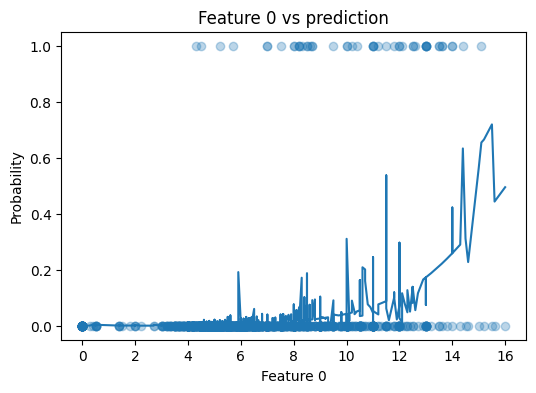

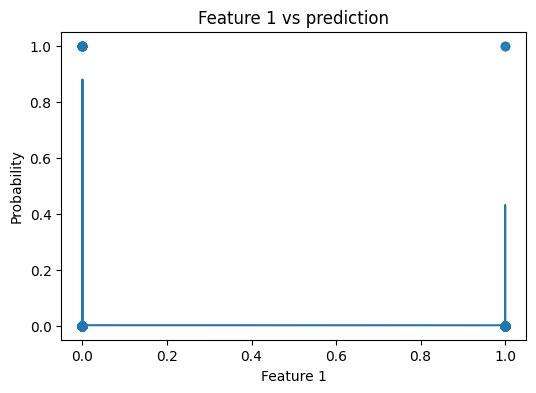

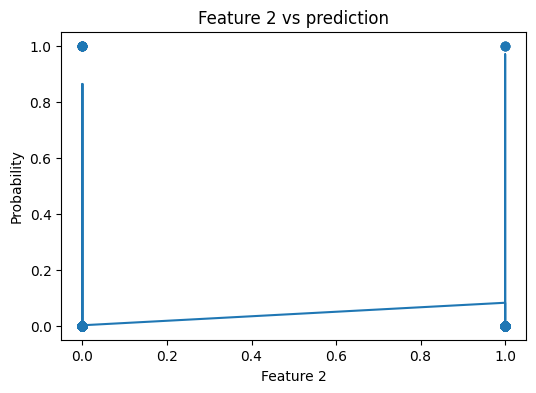

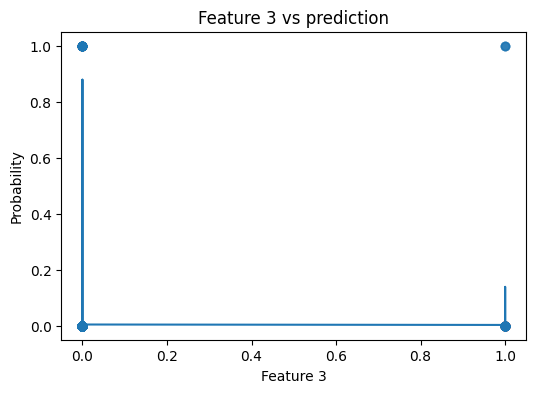

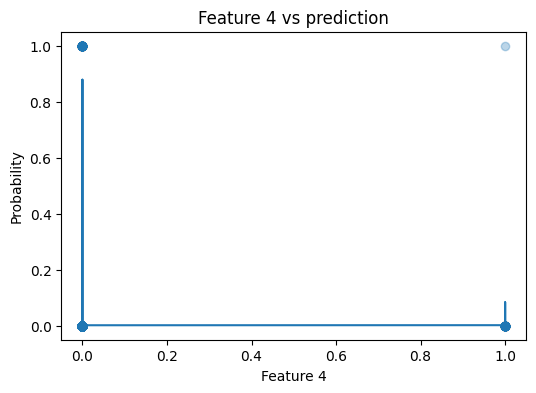

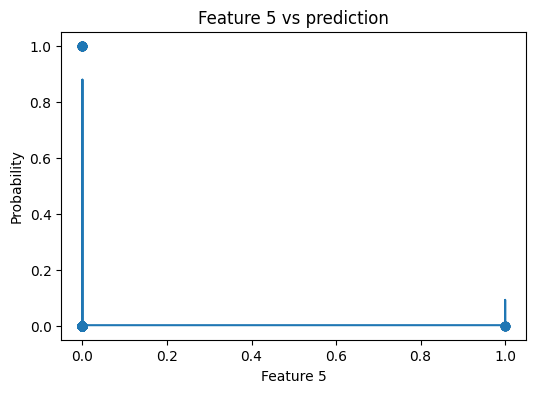

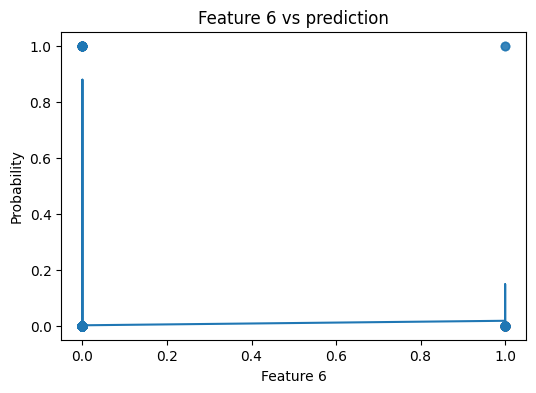

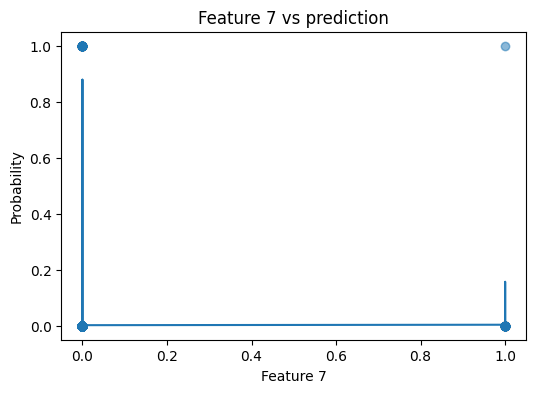

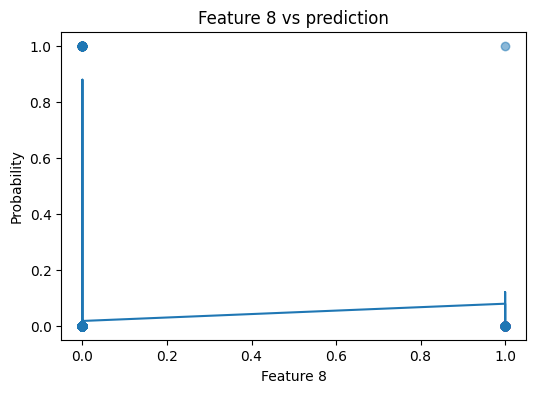

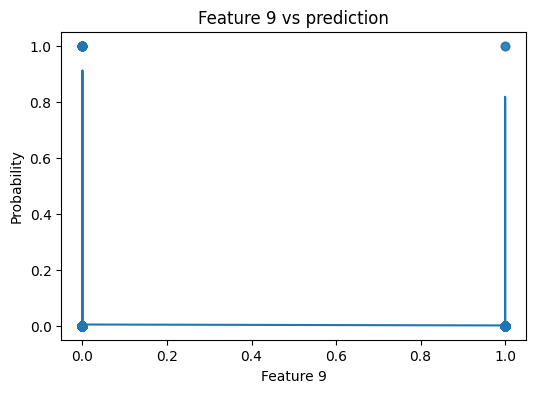

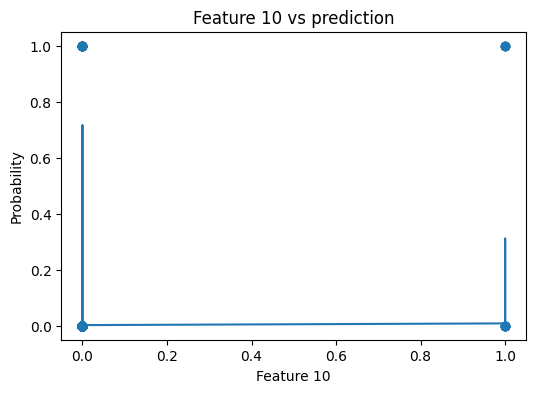

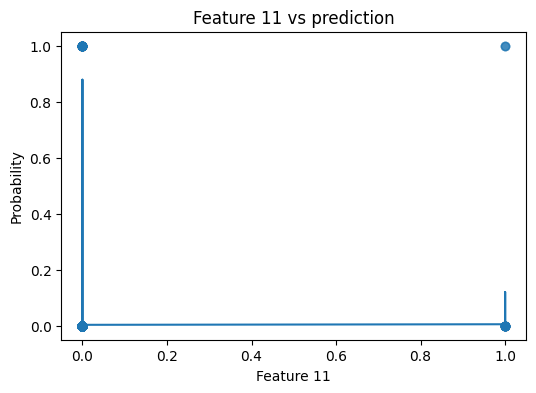

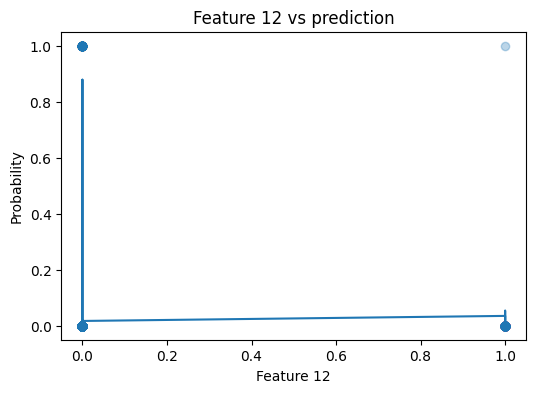

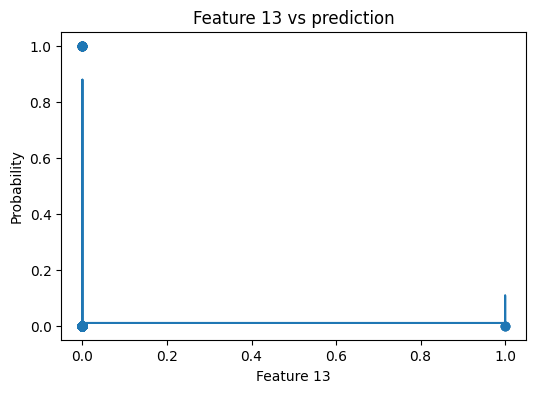

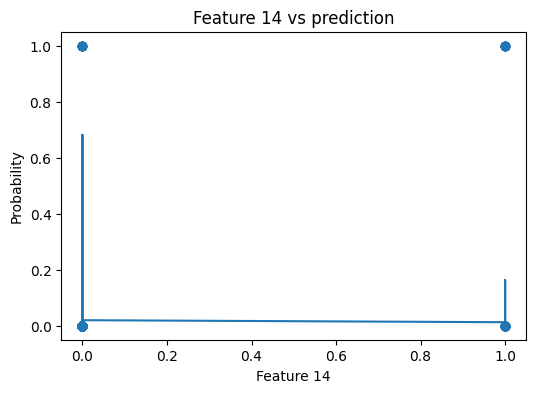

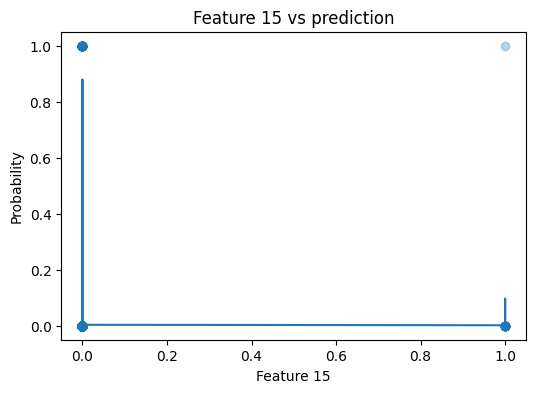

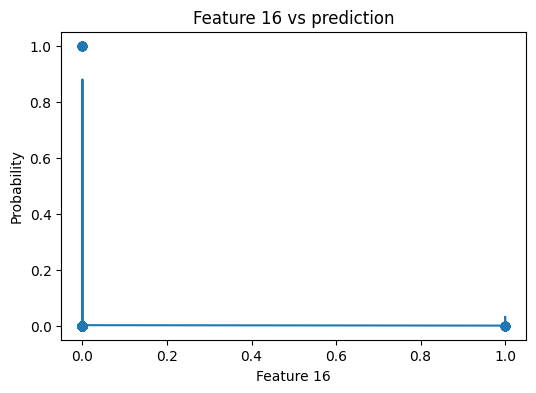

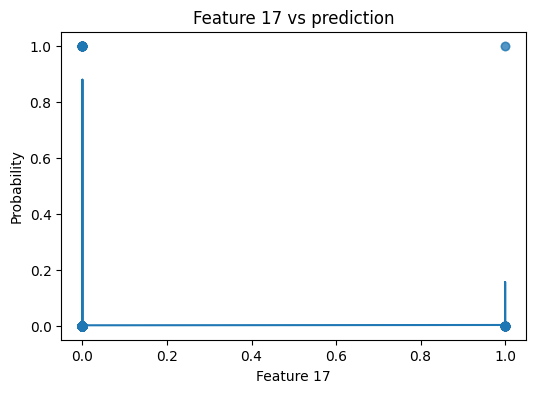

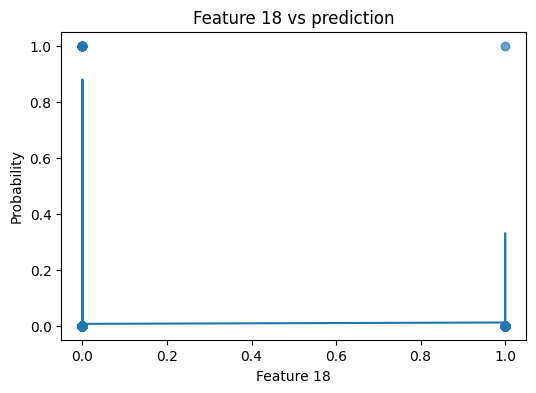

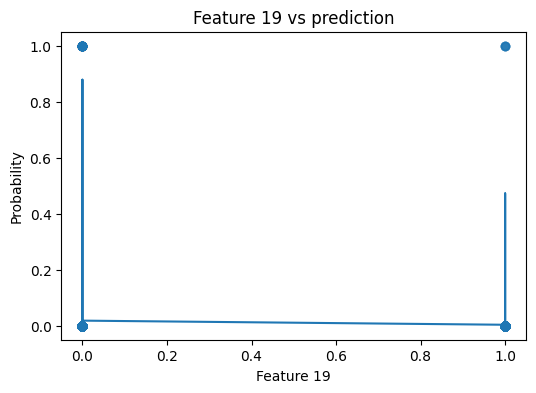

In [102]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

# modell
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

n_features = X.shape[1]

for i in range(n_features):

    x_feature = X[:, i]

    # scatter
    plt.figure(figsize=(6,4))
    plt.scatter(x_feature, y, alpha=0.3)

    # rendezés a szép görbéhez
    idx = np.argsort(x_feature)

    x_sorted = x_feature[idx]

    # teljes X másolása
    X_temp = X.copy()

    # csak az i-edik feature változik
    X_temp[:, i] = x_sorted

    # valószínűségek
    y_prob = model.predict_proba(X_temp)[:, 1]

    # görbe
    plt.plot(x_sorted, y_prob)

    plt.xlabel(f"Feature {i}")
    plt.ylabel("Probability")
    plt.title(f"Feature {i} vs prediction")

    plt.show()